# Session 13 — Reversible training: a 20M LLM, three ways

**Stephen Raj Arokiasamy**

The assignment:

1. Train a ~20M-parameter LLM for 50M tokens at a batch size that fits.
2. Train it again with a **reversible** stack, and report which variant worked.
3. Train the reversible model again at the **largest batch that fits**.
4. Report final loss, tokens per second, peak memory, and anything else found.

A reversible stack does not store the activations of each layer. It keeps the two states at the top
of the stack and, during the backward pass, runs the layer update *in reverse* to rebuild each
layer's input from its output. So the memory for activations stops growing with depth, and every
layer runs forward twice.

Three rules shape the notebook:

* **The memory trick is tested separately from the architecture.** A reversible model differs from
  the baseline in two ways: the layer update rule (midpoint instead of residual), and the backward
  pass that rebuilds activations instead of reading them. I check the second one against ordinary
  autograd on the *same* update rule before training anything. If the gradients match, any change in
  loss comes from the architecture and not from the memory trick.
* **Every number below is measured in this run and printed from a variable**, never typed in.
* **Memory is measured two ways**: CUDA's peak allocation, and the exact number of bytes autograd
  saves for the backward pass. The second is independent of the allocator and the device.

| | |
|---|---|
| model | GPT, `d=256`, 10 layers, 4 heads, context 512, GPT-2 vocabulary, tied embeddings — **~20.9M parameters** |
| data | FineWeb-Edu `sample-10BT`, GPT-2 BPE, **one pass over 50M tokens**, the same token order for every run |
| hardware | free Colab **T4**: fp16 with a loss scaler (the T4 has no native bf16) |
| variants | midpoint · midpoint(a) with Euler bootstrap · midpoint(a) without it · leapfrog |

**Running it.** Choose Runtime → T4 GPU, then Run all, and approve the Google Drive prompt. The
notebook trains about 175M tokens in total: a 5-variant screen plus three 50M-token runs. Once the
screen has measured the real throughput, it prints a projected finish time.

**If Colab disconnects, reconnect and Run all again.** Everything that must survive goes to
`MyDrive/s13_runs`:

* the tokenized data, so it is not downloaded twice;
* each finished run's result;
* a checkpoint of the run in progress, saved every five minutes.

Finished runs are loaded rather than retrained. The interrupted run resumes from its checkpoint, on
exactly the batches it would have seen. The batch-size search saves after each of its three
configurations.

In [1]:
import os, sys, math, time, json, gc, hashlib, subprocess
OFFLINE = os.environ.get("S13_OFFLINE") == "1"          # used by verify_local.py only
if not OFFLINE:
    try:
        import tiktoken, datasets                          # noqa: F401
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "-q", "install", "tiktoken", "datasets"],
                       check=True)
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F

SEED = 13
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GPU = torch.cuda.get_device_name(0) if DEVICE == "cuda" else "cpu"
if DEVICE == "cuda":
    CAP = torch.cuda.get_device_capability()
    # the T4 is compute capability 7.5: bf16 is emulated there, so fp16 + loss scaling it is
    AMP_DTYPE = torch.bfloat16 if CAP[0] >= 8 else torch.float16
    GPU_GIB = torch.cuda.get_device_properties(0).total_memory / 2**30
else:
    CAP, AMP_DTYPE, GPU_GIB = None, torch.float32, None
USE_AMP = AMP_DTYPE != torch.float32
USE_SCALER = AMP_DTYPE == torch.float16

def envi(k, d): return int(os.environ.get(k, d))

if OFFLINE:   # a miniature of the real configuration, so every cell runs on a laptop CPU
    CFG = dict(vocab=512, d=64, layers=6, heads=2, seq=64, batch=8,
               train_tokens=envi("S13_TOKENS", 40_000), screen_tokens=envi("S13_SCREEN", 12_000),
               val_tokens=16_384, eval_seqs=32, final_eval_seqs=64, lr=3e-3)
else:
    CFG = dict(vocab=50304, d=256, layers=10, heads=4, seq=512, batch=32,
               train_tokens=envi("S13_TOKENS", 50_000_000), screen_tokens=envi("S13_SCREEN", 5_000_000),
               val_tokens=1_048_576, eval_seqs=128, final_eval_seqs=512, lr=1e-3)
T = CFG["seq"]
# Colab wipes /content when the runtime disconnects, so by default everything that must survive -
# the tokenized data, finished results and mid-run checkpoints - goes to Google Drive.
# S13_RUN_DIR overrides the location; S13_NO_DRIVE=1 keeps it local.
RUN_DIR = os.environ.get("S13_RUN_DIR")
if RUN_DIR is None:
    RUN_DIR = "s13_runs"
    if os.path.isdir("/content"):
        RUN_DIR = "/content/s13_runs"
        if not OFFLINE and os.environ.get("S13_NO_DRIVE") != "1":
            try:
                from google.colab import drive
                drive.mount("/content/drive")
                RUN_DIR = "/content/drive/MyDrive/s13_runs"
            except Exception as e:
                print("Drive not mounted, results stay in /content and will NOT survive a disconnect:", e)
os.makedirs(RUN_DIR, exist_ok=True)
CKPT_SECONDS = envi("S13_CKPT_SECONDS", 300)            # mid-run checkpoint interval
FORCE = os.environ.get("S13_FORCE") == "1"               # re-run even if a result file exists

print("torch     ", torch.__version__)
print("device    ", DEVICE, "|", GPU, f"| {GPU_GIB:.1f} GiB" if GPU_GIB else "")
print("precision ", AMP_DTYPE, "| loss scaler" if USE_SCALER else "")
print("config    ", CFG)
print("results   ", RUN_DIR)
print(f"checkpoint every {CKPT_SECONDS}s inside each run; after a disconnect, Run all resumes from"
      " the last checkpoint")

Drive not mounted, results stay in /content and will NOT survive a disconnect: Error: credential propagation was unsuccessful
torch      2.11.0+cu128
device     cuda | Tesla T4 | 14.6 GiB
precision  torch.float16 | loss scaler
config     {'vocab': 50304, 'd': 256, 'layers': 10, 'heads': 4, 'seq': 512, 'batch': 32, 'train_tokens': 50000000, 'screen_tokens': 5000000, 'val_tokens': 1048576, 'eval_seqs': 128, 'final_eval_seqs': 512, 'lr': 0.001}
results    /content/s13_runs
checkpoint every 300s inside each run; after a disconnect, Run all resumes from the last checkpoint


## 1 · Data: 50M tokens of FineWeb-Edu

The data is streamed from Hugging Face, tokenized with GPT-2 BPE (`tiktoken`), and written once to a
`uint16` file. The first 1M tokens become the validation set. Training reads the next 50M tokens as
windows of 512 in a **fixed random order drawn once from the seed**, so:

* every token is seen exactly once (one epoch, no repeats);
* the two fixed-batch runs see **identical batches in identical order**, so the only thing that
  differs between them is the model;
* the max-batch run sees the same tokens in the same order, just grouped into bigger steps.

In [2]:
DATA_DIR = os.path.join(RUN_DIR, "data")
os.makedirs(DATA_DIR, exist_ok=True)
n_chunks_needed = math.ceil(CFG["train_tokens"] / T)
N_TRAIN = n_chunks_needed * T + 1                         # +1 so the last window has a target
N_VAL = CFG["val_tokens"]

def build_fineweb(path, need):
    import tiktoken
    from datasets import load_dataset
    enc = tiktoken.get_encoding("gpt2"); eot = enc.eot_token
    ds = load_dataset("HuggingFaceFW/fineweb-edu", name="sample-10BT", split="train", streaming=True)
    buf = np.empty(need, dtype=np.uint16); pos = docs = 0; pending = []
    t0 = time.time()
    for ex in ds:
        pending.append(ex["text"])
        if len(pending) < 512:
            continue
        for ids in enc.encode_ordinary_batch(pending, num_threads=8):
            ids.append(eot)
            n = min(len(ids), need - pos)
            buf[pos:pos + n] = ids[:n]; pos += n; docs += 1
            if pos >= need: break
        pending = []
        if pos >= need: break
        if docs % 20480 < 512:
            print(f"  {pos/1e6:6.1f}M tokens from {docs:,} documents  ({time.time()-t0:.0f}s)")
    assert pos == need, f"stream ended early at {pos} tokens"
    buf.tofile(path + ".tmp"); os.replace(path + ".tmp", path)   # no half-written file after a crash
    return docs

def build_synthetic(path, need, vocab):
    # offline stand-in: a sparse random bigram language, so the loss has something to learn
    rng = np.random.default_rng(SEED)
    succ = rng.integers(0, vocab, size=(vocab, 8))
    toks = np.empty(need, dtype=np.uint16); toks[0] = 0
    choice = rng.integers(0, 8, size=need)
    for i in range(1, need):
        toks[i] = succ[toks[i-1], choice[i]]
    toks.tofile(path)
    return 0

name = "synthetic" if OFFLINE else "fineweb_edu_gpt2"
bin_path = os.path.join(DATA_DIR, f"{name}_{N_VAL + N_TRAIN}.bin")
man_path = bin_path + ".json"
if not os.path.exists(man_path):
    t0 = time.time()
    docs = (build_synthetic(bin_path, N_VAL + N_TRAIN, CFG["vocab"]) if OFFLINE
            else build_fineweb(bin_path, N_VAL + N_TRAIN))
    sha = hashlib.sha256(open(bin_path, "rb").read()).hexdigest()
    json.dump(dict(source=name, tokens=N_VAL + N_TRAIN, documents=docs, sha256=sha,
                   seconds=round(time.time() - t0, 1)), open(man_path, "w"), indent=1)
MANIFEST = json.load(open(man_path))
ALL = np.fromfile(bin_path, dtype=np.uint16)
assert len(ALL) == MANIFEST["tokens"]
VAL, TRAIN = ALL[:N_VAL], ALL[N_VAL:]

N_CHUNKS = (len(TRAIN) - 1) // T
PERM = np.random.default_rng(SEED).permutation(N_CHUNKS)   # one epoch, one fixed order for all runs

def chunk_batch(ids, src=None):
    src = TRAIN if src is None else src
    x = np.stack([src[i*T:i*T + T + 1] for i in ids]).astype(np.int64)
    x = torch.from_numpy(x)
    if DEVICE == "cuda": x = x.pin_memory().to(DEVICE, non_blocking=True)
    return x[:, :-1], x[:, 1:]

VAL_CHUNKS = (len(VAL) - 1) // T
print(f"source      {MANIFEST['source']}  ({MANIFEST['documents']:,} documents)")
print(f"sha256      {MANIFEST['sha256'][:16]}...")
print(f"validation  {len(VAL):,} tokens -> {VAL_CHUNKS:,} windows of {T}")
print(f"training    {N_CHUNKS:,} windows of {T} = {N_CHUNKS*T:,} tokens, one epoch, fixed order")

README.md:   0%|          | 0.00/26.4k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

    21.3M tokens from 20,480 documents  (28s)
    42.8M tokens from 40,960 documents  (50s)
source      fineweb_edu_gpt2  (48,508 documents)
sha256      1a6babadb992208e...
validation  1,048,576 tokens -> 2,047 windows of 512
training    97,657 windows of 512 = 50,000,384 tokens, one epoch, fixed order


## 2 · The model, and one decision that has nothing to do with reversibility

Each transformer block computes an *update* `f(p)`, not a new state. It is the block from the paper's
equation 2.5:

$$f_\ell(p) = \mathrm{Attn}_\ell(\mathrm{LN}_1 p) + \mathrm{MLP}_\ell\big(\mathrm{LN}_2(p + \mathrm{Attn}_\ell(\mathrm{LN}_1 p))\big)$$

With the ordinary rule `p ← p + f(p)`, this block is exactly a standard pre-LayerNorm GPT block. So the
baseline and every reversible model share **the same block and the same parameters**. They differ
only in how successive states are combined. That is what makes the comparison fair.

**The loss head.** A 20M model with a 50,304-token vocabulary has an unusual memory profile. The
logits for one token are 50,304 numbers, while that token's hidden state is only 256 numbers. For
every token, the naive head keeps the fp16 logits, an fp32 copy for the softmax, and the gradient of
each. That comes to hundreds of kilobytes per token, far more than all ten layers' activations
together. Left alone, it would decide the batch size for *both* models and hide the effect of
reversibility completely. §4 measures this.

So every run uses a **fused linear + cross-entropy head**. It processes 2,048 tokens at a time,
computes the loss and both gradients inside the forward pass, and keeps only the gradients (one
hidden-sized vector per token, plus one copy of the embedding matrix). The full logit table never
exists. This is the same idea as Liger-Kernel's fused linear cross-entropy. It is checked against
`F.cross_entropy` in §3.

In [3]:
class Attn(nn.Module):
    def __init__(s, d, h):
        super().__init__()
        s.h = h
        s.qkv = nn.Linear(d, 3 * d, bias=False)
        s.proj = nn.Linear(d, d, bias=False)
    def forward(s, x):
        B, L, D = x.shape
        q, k, v = s.qkv(x).view(B, L, 3, s.h, D // s.h).permute(2, 0, 3, 1, 4)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        return s.proj(y.transpose(1, 2).reshape(B, L, D))

class Block(nn.Module):
    # returns the UPDATE f(p) of Gal et al. eq. 2.5, not the next state
    def __init__(s, d, h):
        super().__init__()
        s.ln1, s.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        s.attn = Attn(d, h)
        s.fc, s.fc2 = nn.Linear(d, 4 * d, bias=False), nn.Linear(4 * d, d, bias=False)
    def forward(s, p):
        a = s.attn(s.ln1(p))
        return a + s.fc2(F.gelu(s.fc(s.ln2(p + a))))

# ---- the update rules --------------------------------------------------------------------------
# reversible rules all have the form   p[k+1] = a*p[k-1] + b*p[k] + c*f_k(p[k])
# so they run backwards as             p[k-1] = (p[k+1] - b*p[k] - c*f_k(p[k])) / a
# 'kick' is the bootstrap that makes the second state: p1 = p0 + kick*f_0(p0), or p1 = p0 if None
INTEGRATORS = {
    "baseline":          dict(kind="residual", note="p <- p + f(p); the standard transformer"),
    "midpoint":          dict(kind="rev", a=1.0, b=0.0, c=1.0,  kick=0.25,
                              note="Gal eq. 2.4, h=0.5 so 2h=1; half-step Euler bootstrap"),
    "midpoint_a":        dict(kind="rev", a=0.5, b=0.5, c=0.25, kick=0.125,
                              note="midpoint(a), Gal eq. 3.6; Lightning LM production: h=0.25, a=0.5, bootstrap=euler"),
    "midpoint_a_nokick": dict(kind="rev", a=0.5, b=0.5, c=0.25, kick=None,
                              note="the same rule with bootstrap=no_kick (p1 = p0)"),
    "leapfrog":          dict(kind="rev", a=-1.0, b=2.0, c=0.25, kick=0.125,
                              note="Gal eq. 2.6, the wave equation: h=0.5 so h^2=0.25; bootstrap h^2/2"),
}
REV_VARIANTS = [k for k, v in INTEGRATORS.items() if v["kind"] == "rev"]

def run_plain(p0, blocks, g, keep=False):
    # ordinary autograd through the rule: every intermediate is stored for the backward pass
    states = [p0]
    if g["kind"] == "residual":
        p = p0
        for B in blocks:
            p = p + B(p); states.append(p)
        return (p, states) if keep else p
    prev = p0
    if g["kick"] is None:
        cur, seq = p0, list(blocks)
    else:
        cur, seq = p0 + g["kick"] * blocks[0](p0), list(blocks)[1:]
    states.append(cur)
    for B in seq:
        prev, cur = cur, g["a"] * prev + g["b"] * cur + g["c"] * B(cur)
        states.append(cur)
    return (cur, states) if keep else cur

In [4]:
class RevStack(torch.autograd.Function):
    # The memory-saving backward. The forward runs with no graph and saves only the top two states.
    # The backward walks down the stack: at each layer it re-runs the block on the state it holds,
    # rebuilds the state below from the rule, and back-propagates through that one block only.

    @staticmethod
    @torch.amp.custom_fwd(device_type="cuda")
    def forward(ctx, p0, lm, *params):
        g, blocks = lm.integ, list(lm.blocks)
        prev = p0
        if g["kick"] is None:
            cur, seq = p0, blocks
        else:
            cur, seq = p0 + g["kick"] * blocks[0](p0).to(p0.dtype), blocks[1:]
        kept = [p0, cur]
        for B in seq:
            prev, cur = cur, g["a"] * prev + g["b"] * cur + g["c"] * B(cur).to(cur.dtype)
            if lm.oracle: kept.append(cur)
        # oracle=True is a diagnostic: the backward reads the true states instead of rebuilding them,
        # which separates "is the algorithm right" from "how accurate is the reconstruction"
        ctx.kept = kept if lm.oracle else None
        ctx.lm = lm
        ctx.save_for_backward(prev, cur)
        return cur

    @staticmethod
    @torch.amp.custom_bwd(device_type="cuda")
    def backward(ctx, g_out):
        prev, cur = ctx.saved_tensors
        lm = ctx.lm; g = lm.integ; blocks = list(lm.blocks)
        a, b, c, kick = g["a"], g["b"], g["c"], g["kick"]
        seq = blocks if kick is None else blocks[1:]
        grads = {id(p): None for p in lm.rev_params}

        def through(block, x, scale, gy):
            # run one block with a graph, and pull the gradient of scale*f(x) back to x and weights
            with torch.enable_grad():
                xk = x.detach().requires_grad_(True)
                y = block(xk)
                ps = [p for p in block.parameters()]
                out = torch.autograd.grad(y, [xk] + ps, grad_outputs=(scale * gy).to(y.dtype),
                                          allow_unused=True)
            for p, gp in zip(ps, out[1:]):
                if gp is not None:
                    grads[id(p)] = gp if grads[id(p)] is None else grads[id(p)] + gp
            return y.detach().to(x.dtype), out[0].to(x.dtype)

        x_next, x = cur.detach(), prev.detach()
        g_next, g_x = g_out.to(x.dtype), torch.zeros_like(x)
        for j, B in enumerate(reversed(seq)):
            y, gx_block = through(B, x, c, g_next)
            if ctx.kept is not None:
                x_prev = ctx.kept[len(ctx.kept) - 3 - j]      # oracle: the true state
            else:
                x_prev = (x_next - b * x - c * y) / a        # the rule, read right to left
            g_total = g_x + b * g_next + gx_block             # every use of x is now accounted for
            g_x, g_next = a * g_next, g_total                 # x_prev's partial; x's total
            x_next, x = x, x_prev
        # x_next is p1, x is p0 (rebuilt), g_next = dL/dp1 in full, g_x = the rest of dL/dp0
        if kick is None:
            g0 = g_x + g_next
        else:
            _, gx_block = through(blocks[0], x, kick, g_next)
            g0 = g_x + g_next + gx_block
        return (g0, None, *[grads[id(p)] for p in lm.rev_params])


class LM(nn.Module):
    def __init__(s, integ_name, reversible=None):
        super().__init__()
        s.integ_name, s.integ = integ_name, INTEGRATORS[integ_name]
        s.reversible = (s.integ["kind"] == "rev") if reversible is None else reversible
        V, D = CFG["vocab"], CFG["d"]
        s.emb = nn.Embedding(V, D)
        s.pos = nn.Parameter(torch.zeros(1, T, D))
        s.blocks = nn.ModuleList(Block(D, CFG["heads"]) for _ in range(CFG["layers"]))
        s.ln_f = nn.LayerNorm(D)
        s.apply(s._init)
        for n, p in s.named_parameters():                   # GPT-2: scale the residual projections
            if n.endswith("proj.weight") or n.endswith("fc2.weight"):
                nn.init.normal_(p, 0.0, 0.02 / math.sqrt(2 * CFG["layers"]))
        s.rev_params = [p for B in s.blocks for p in B.parameters()]
        s.oracle = False

    @staticmethod
    def _init(m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, 0.0, 0.02)

    def embed(s, idx):
        return s.emb(idx) + s.pos[:, :idx.shape[1]]

    def hidden(s, idx):
        p0 = s.embed(idx)
        if s.reversible and torch.is_grad_enabled():
            p = RevStack.apply(p0, s, *s.rev_params)
        else:
            p = run_plain(p0, s.blocks, s.integ)
        return s.ln_f(p)

    def forward(s, idx, targets, head="fused"):
        h = s.hidden(idx).reshape(-1, CFG["d"])
        t = targets.reshape(-1)
        if head == "naive":
            return F.cross_entropy((h @ s.emb.weight.t()).float(), t)
        return fused_ce(h, s.emb.weight, t)


class FusedLinearCE(torch.autograd.Function):
    # loss = mean CE(h @ W^T, t), computed 2,048 tokens at a time; both gradients are formed in
    # the forward pass, so the (tokens x vocab) logit table never exists in full
    @staticmethod
    def forward(ctx, h, W, t, need_grad, chunk=2048):
        # follow the caller: inside autocast use its dtype, outside it stay in fp32. (An earlier
        # build always used the AMP dtype on CUDA, so its "fp32" check was really a 16-bit one.)
        cd = AMP_DTYPE if (h.is_cuda and torch.is_autocast_enabled()) else torch.float32
        Wc = W.to(cd)
        N = h.shape[0]
        loss = torch.zeros((), dtype=torch.float32, device=h.device)
        gh = torch.empty(h.shape, dtype=torch.float32, device=h.device) if need_grad else None
        gW = torch.zeros(W.shape, dtype=torch.float32, device=h.device) if need_grad else None
        for i in range(0, N, chunk):
            hc, tc = h[i:i + chunk].to(cd), t[i:i + chunk]
            logits = (hc @ Wc.t()).float()
            lse = torch.logsumexp(logits, dim=-1)
            loss += (lse - logits.gather(1, tc[:, None]).squeeze(1)).sum()
            if need_grad:
                # (softmax - onehot) lies in [-1, 1], which fp16 holds well. Dividing by N first
                # would push most entries below fp16's normal range (6e-5) at 16k tokens per step;
                # standard AMP avoids that because the loss scale is applied before the cast. So
                # the 1/N is applied after the matmul, in fp32.
                probs = torch.exp(logits - lse[:, None])
                probs[torch.arange(len(tc), device=h.device), tc] -= 1.0
                probs = probs.to(cd)
                gh[i:i + chunk] = (probs @ Wc).float() / N
                gW += (probs.t() @ hc).float() / N
        if need_grad:
            ctx.save_for_backward(gh, gW)
        ctx.dt = (h.dtype, W.dtype)
        return loss / N

    @staticmethod
    def backward(ctx, go):
        gh, gW = ctx.saved_tensors
        return (gh * go).to(ctx.dt[0]), (gW * go).to(ctx.dt[1]), None, None, None

def fused_ce(h, W, t):
    need = torch.is_grad_enabled() and (h.requires_grad or W.requires_grad)
    return FusedLinearCE.apply(h, W, t, need)

m = LM("baseline")
N_PARAMS = sum(p.numel() for p in m.parameters())
N_EMB = m.emb.weight.numel() + m.pos.numel()
N_BLOCKS = sum(p.numel() for p in m.rev_params)
print(f"parameters  {N_PARAMS:,} total  (= {N_PARAMS/1e6:.2f}M)")
print(f"  embedding {N_EMB:,}  (tied: the same matrix is the output head)")
print(f"  blocks    {N_BLOCKS:,}  = {CFG['layers']} x {N_BLOCKS // CFG['layers']:,}")
print(f"  final LN  {N_PARAMS - N_EMB - N_BLOCKS:,}")
print(f"\nupdate rules:")
for k, v in INTEGRATORS.items():
    print(f"  {k:<18} {v['note']}")
del m

parameters  20,883,968 total  (= 20.88M)
  embedding 13,008,896  (tied: the same matrix is the output head)
  blocks    7,874,560  = 10 x 787,456
  final LN  512

update rules:
  baseline           p <- p + f(p); the standard transformer
  midpoint           Gal eq. 2.4, h=0.5 so 2h=1; half-step Euler bootstrap
  midpoint_a         midpoint(a), Gal eq. 3.6; Lightning LM production: h=0.25, a=0.5, bootstrap=euler
  midpoint_a_nokick  the same rule with bootstrap=no_kick (p1 = p0)
  leapfrog           Gal eq. 2.6, the wave equation: h=0.5 so h^2=0.25; bootstrap h^2/2


## 3 · Before training: is the memory trick exact?

Three checks, all run before any training.

**(a) The fused head against `F.cross_entropy`.** Same loss, same gradient for the hidden states, same
gradient for the embedding matrix.

**(b) The reversible backward against ordinary autograd, on the same update rule.** For each variant I
build two copies of one model with identical weights. One trains through `RevStack`, which stores two
states. The other runs the same rule through plain autograd, which stores everything. I compare every
parameter's gradient. At initialisation each block's update is tiny, because GPT-2 initialisation
scales the output projections down. That makes the test too easy, so I repeat it with the block
weights multiplied by 4, which makes each update comparable in size to the state it is added to.

**(c) How exact is "exact"?** Reversal is exact in real numbers, not in floating point. Each rebuilt
state carries the rounding error of every step above it, and the update rule decides whether that
error grows. Ignore `f` for a moment and the rule is a linear recurrence `p[k+1] = a·p[k-1] + b·p[k]`.
Its growth factors are the roots of `r² − b·r − a = 0`. Running the rule backwards inverts them. So a
rule that **damps** a mode going forward **amplifies** that same mode going backward, by `1/|r|` per
layer.

| rule | a, b | forward roots | backward growth per layer |
|---|---|---|---|
| midpoint | 1, 0 | ±1 | 1 — marginal: rounding error neither grows nor shrinks |
| midpoint(a) | 0.5, 0.5 | 1, −0.5 | **2** — rounding error doubles with every layer |
| leapfrog | −1, 2 | 1, 1 (double) | 1, but a double root: error grows linearly |

This is the paper's warning that reversible networks are only *marginally stable*, seen from the other
side. The damping that makes midpoint(a) well-behaved in the forward pass is exactly what makes its
reconstruction ill-conditioned. The cell below measures the reconstruction error layer by layer, with
states held in fp32 (as training does) and in fp16 (as a careless implementation might).

In [5]:
# (a) fused head vs F.cross_entropy -----------------------------------------------------------
torch.manual_seed(0)
Nt = 3000 if not OFFLINE else 700                       # not a multiple of the 2,048 chunk
h = torch.randn(Nt, CFG["d"], device=DEVICE, requires_grad=True)
W = (0.05 * torch.randn(CFG["vocab"], CFG["d"], device=DEVICE)).requires_grad_(True)
t = torch.randint(0, CFG["vocab"], (Nt,), device=DEVICE)
ref = F.cross_entropy(h @ W.t(), t)
gh_ref, gW_ref = torch.autograd.grad(ref, [h, W])
out = fused_ce(h, W, t)
gh, gW = torch.autograd.grad(out, [h, W])
CE_CHECK = dict(loss=abs(out.item() - ref.item()),
                gh=((gh - gh_ref).norm() / gh_ref.norm()).item(),
                gW=((gW - gW_ref).norm() / gW_ref.norm()).item())
print("(a) fused linear+CE head vs F.cross_entropy, fp32, "
      f"{Nt:,} tokens (the last chunk is partial)")
print(f"    |loss difference|            {CE_CHECK['loss']:.2e}")
print(f"    relative error, dL/dh        {CE_CHECK['gh']:.2e}")
print(f"    relative error, dL/dW        {CE_CHECK['gW']:.2e}")
del h, W, t, ref, gh_ref, gW_ref, out, gh, gW

if USE_AMP and DEVICE == "cuda":
    # the same check in the precision training uses, at the real tokens-per-step, against an fp32
    # reference - and against the version that divides by N before the fp16 cast
    torch.manual_seed(1)
    Nb = CFG["batch"] * T
    h = torch.randn(Nb, CFG["d"], device=DEVICE)
    W = 0.05 * torch.randn(CFG["vocab"], CFG["d"], device=DEVICE)
    t = torch.randint(0, CFG["vocab"], (Nb,), device=DEVICE)
    hr, Wr = h.clone().requires_grad_(True), W.clone().requires_grad_(True)
    gh_ref, gW_ref = torch.autograd.grad(F.cross_entropy(hr @ Wr.t(), t), [hr, Wr])
    hf, Wf = h.clone().requires_grad_(True), W.clone().requires_grad_(True)
    with torch.autocast(DEVICE, dtype=AMP_DTYPE):
        gh16, gW16 = torch.autograd.grad(fused_ce(hf, Wf, t), [hf, Wf])
    gW_early = torch.zeros_like(W); Wc = W.to(AMP_DTYPE)
    for i in range(0, Nb, 2048):                           # the bug, reproduced on purpose
        lg = (h[i:i+2048].to(AMP_DTYPE) @ Wc.t()).float()
        pr = torch.softmax(lg, -1); pr[torch.arange(len(lg), device=DEVICE), t[i:i+2048]] -= 1
        gW_early += ((pr / Nb).to(AMP_DTYPE).t() @ h[i:i+2048].to(AMP_DTYPE)).float()
    rel = lambda a_, b_: ((a_ - b_).norm() / b_.norm()).item()
    CE_CHECK.update(amp_gh=rel(gh16, gh_ref), amp_gW=rel(gW16, gW_ref), early_gW=rel(gW_early, gW_ref))
    TINY = torch.finfo(AMP_DTYPE).tiny
    tiny = ((torch.softmax((h[:2048] @ W.t()), -1) / Nb) < TINY).float().mean().item()
    print(f"\n    same check in {str(AMP_DTYPE).split('.')[-1]}, {Nb:,} tokens (one training step), vs an fp32 reference:")
    print(f"    relative error, dL/dh        {CE_CHECK['amp_gh']:.2e}")
    print(f"    relative error, dL/dW        {CE_CHECK['amp_gW']:.2e}")
    print(f"    ...if 1/N is applied BEFORE the fp16 cast: dL/dW error {CE_CHECK['early_gW']:.2e}")
    fmt = str(AMP_DTYPE).split('.')[-1]
    print(f"    ({100*tiny:.1f}% of the entries of softmax/N fall below {fmt}'s smallest normal number,"
          f" {TINY:.1e}.")
    if AMP_DTYPE == torch.float16:
        print("     In fp16 that is fatal to precision, so the division is done after the matmul, in fp32.)")
    else:
        print("     bf16 keeps fp32's exponent range, so here early division costs nothing; the fix matters")
        print("     on fp16 hardware such as the T4.)")
    # lg, pr (two fp32 2,048 x vocab chunks) and Wc must go too: an earlier build left them alive,
    # and their 810.6 MiB sat inside every CUDA peak measured after this cell
    del h, W, t, hr, Wr, hf, Wf, gh_ref, gW_ref, gh16, gW16, gW_early, lg, pr, Wc
    gc.collect(); torch.cuda.empty_cache()

(a) fused linear+CE head vs F.cross_entropy, fp32, 3,000 tokens (the last chunk is partial)
    |loss difference|            9.54e-07
    relative error, dL/dh        1.76e-06
    relative error, dL/dW        1.23e-06

    same check in float16, 16,384 tokens (one training step), vs an fp32 reference:
    relative error, dL/dh        5.28e-04
    relative error, dL/dW        2.94e-04
    ...if 1/N is applied BEFORE the fp16 cast: dL/dW error 2.91e-02
    (100.0% of the entries of softmax/N fall below float16's smallest normal number, 6.1e-05.
     In fp16 that is fatal to precision, so the division is done after the matmul, in fp32.)


In [6]:
# (b) reversible backward vs plain autograd through the SAME rule ------------------------------
def grad_compare(integ, stress=1.0, amp=False, batch=2, seed=0, oracle=False, state=None):
    torch.manual_seed(seed)
    rev = LM(integ, reversible=True).to(DEVICE)
    if state is not None: rev.load_state_dict(state)
    rev.oracle = oracle
    if stress != 1.0:
        with torch.no_grad():
            for B in rev.blocks:
                for n_, p in B.named_parameters():
                    if p.dim() == 2: p.mul_(stress)
    plain = LM(integ, reversible=False).to(DEVICE)
    plain.load_state_dict(rev.state_dict())
    x, y = chunk_batch(range(batch))
    out = {}
    for tag, mdl in (("rev", rev), ("plain", plain)):
        mdl.zero_grad(set_to_none=True)
        with torch.autocast(DEVICE, dtype=AMP_DTYPE, enabled=amp and USE_AMP):
            loss = mdl(x, y)
        loss.backward()
        out[tag] = (loss.item(), {n_: p.grad.detach().clone() for n_, p in mdl.named_parameters()
                                  if p.grad is not None})
    worst, where = 0.0, ""
    for n_, g_ in out["plain"][1].items():
        den = g_.norm().item()
        if den == 0: continue
        e = (out["rev"][1][n_] - g_).norm().item() / den
        if e > worst: worst, where = e, n_
    return dict(loss_gap=abs(out["rev"][0] - out["plain"][0]), worst=worst, where=where)

GRAD_CHECK = {}
print("(b) reversible backward vs ordinary autograd, same weights, same rule, same batch")
print("    'oracle' = the reversible backward fed the TRUE states (tests the algorithm);")
print("    'rebuilt' = the real thing, states reconstructed by running the rule backwards\n")
print(f"    {'rule':<18}{'weights':<9}{'precision':<10}{'oracle':>12}{'rebuilt':>12}   worst param")
for integ in REV_VARIANTS:
    for stress in (1.0, 4.0):
        for amp in ((False, True) if USE_AMP else (False,)):
            o = grad_compare(integ, stress=stress, amp=amp, oracle=True)
            r = grad_compare(integ, stress=stress, amp=amp, oracle=False)
            GRAD_CHECK[(integ, stress, amp)] = dict(oracle=o["worst"], rebuilt=r["worst"],
                                                    loss_gap=r["loss_gap"], where=r["where"])
            prec = str(AMP_DTYPE).split(".")[-1] if amp else "fp32"
            print(f"    {integ:<18}{'x' + str(stress):<9}{prec:<10}{o['worst']:>12.2e}"
                  f"{r['worst']:>12.2e}   {r['where']}")
FP32_ORACLE = max(v["oracle"] for (i, s_, a_), v in GRAD_CHECK.items() if not a_)
FP32_REBUILT = max(v["rebuilt"] for (i, s_, a_), v in GRAD_CHECK.items() if not a_)
print(f"\n    worst fp32 error, oracle states  : {FP32_ORACLE:.2e}   <- the algorithm")
print(f"    worst fp32 error, rebuilt states : {FP32_REBUILT:.2e}   <- algorithm + reconstruction")
print("    With the true states the reversible backward reproduces autograd to fp32 rounding, so")
print("    the backward pass itself is right. What remains is reconstruction error, measured in (c).")
print("    Any loss difference in training therefore comes from the rule or from reconstruction,")
print("    never from a wrong gradient formula.")

(b) reversible backward vs ordinary autograd, same weights, same rule, same batch
    'oracle' = the reversible backward fed the TRUE states (tests the algorithm);
    'rebuilt' = the real thing, states reconstructed by running the rule backwards

    rule              weights  precision       oracle     rebuilt   worst param
    midpoint          x1.0     fp32          4.17e-07    7.23e-06   blocks.0.attn.proj.weight
    midpoint          x1.0     float16       4.67e-03    6.68e-03   blocks.0.ln2.weight
    midpoint          x4.0     fp32          6.68e-07    5.35e-04   blocks.0.ln1.weight
    midpoint          x4.0     float16       1.76e-02    3.00e-01   blocks.0.ln1.weight
    midpoint_a        x1.0     fp32          3.18e-07    6.17e-05   blocks.0.attn.proj.weight
    midpoint_a        x1.0     float16       1.29e-02    2.32e-02   blocks.0.ln1.weight
    midpoint_a        x4.0     fp32          7.58e-07    1.10e-02   blocks.0.fc.weight
    midpoint_a        x4.0     float16       

In [7]:
# (c) reconstruction error, layer by layer -----------------------------------------------------
def backward_growth(g):
    r = np.roots([1.0, -g["b"], -g["a"]])
    inv = 1.0 / np.abs(r)
    double = abs(r[0] - r[1]) < 1e-9
    return float(inv.max()), bool(double)

@torch.no_grad()
def recon_errors(integ, state_dtype, stress=1.0, amp=True, batch=2, seed=0, state=None):
    torch.manual_seed(seed)
    m_ = LM(integ).to(DEVICE)
    if state is not None: m_.load_state_dict(state)
    if stress != 1.0:
        for B in m_.blocks:
            for p in B.parameters():
                if p.dim() == 2: p.mul_(stress)
    g, blocks = m_.integ, list(m_.blocks)
    x, _ = chunk_batch(range(batch))
    with torch.autocast(DEVICE, dtype=AMP_DTYPE, enabled=amp and USE_AMP):
        sd = state_dtype
        p0 = m_.embed(x).to(sd)
        f = lambda B, p: B(p).to(sd)
        if g["kick"] is None:
            states, seq = [p0, p0], blocks
        else:
            states, seq = [p0, (p0 + g["kick"] * f(blocks[0], p0)).to(sd)], blocks[1:]
        for B in seq:
            states.append((g["a"] * states[-2] + g["b"] * states[-1] + g["c"] * f(B, states[-1])).to(sd))
        xn, xc = states[-1], states[-2]
        rebuilt = []
        for B in reversed(seq):
            xp = ((xn - g["b"] * xc - g["c"] * f(B, xc)) / g["a"]).to(sd)
            rebuilt.append(xp)
            xn, xc = xc, xp
    truth = states[:-2][::-1]                       # the states below the top two, top first
    errs = [((r_.float() - t_.float()).norm() / t_.float().norm()).item() for r_, t_ in zip(rebuilt, truth)]
    return errs

RECON = {}
print("(c) relative error of each rebuilt state; column k = k layers below the top pair\n")
for integ in REV_VARIANTS:
    G, dbl = backward_growth(INTEGRATORS[integ])
    theory = "linear" if dbl else f"x{G:.2f}/layer"
    for sd, sdn in ((torch.float32, "fp32"), (torch.float16, "fp16")):
        if sd == torch.float16 and DEVICE == "cpu":
            continue                                 # fp16 matmul on CPU is not the point here
        for stress in (1.0, 4.0):
            e = recon_errors(integ, sd, stress=stress)
            nz = [v for v in e if v > 0]
            meas = (nz[-1] / nz[0]) ** (1 / max(len(nz) - 1, 1)) if len(nz) > 1 else float("nan")
            RECON[(integ, sdn, stress)] = dict(errs=e, bottom=e[-1], growth=meas, theory=G, double=dbl)
            print(f"  {integ:<18} states {sdn}  weights x{stress:<3}  theory {theory:<12}"
                  f" measured x{meas:5.2f}/layer   bottom state err {e[-1]:.1e}")

(c) relative error of each rebuilt state; column k = k layers below the top pair

  midpoint           states fp32  weights x1.0  theory x1.00/layer  measured x 4.46/layer   bottom state err 2.9e-03
  midpoint           states fp32  weights x4.0  theory x1.00/layer  measured x 7.15/layer   bottom state err 1.4e-01
  midpoint           states fp16  weights x1.0  theory x1.00/layer  measured x 1.47/layer   bottom state err 5.3e-03
  midpoint           states fp16  weights x4.0  theory x1.00/layer  measured x 2.38/layer   bottom state err 2.5e-01
  midpoint_a         states fp32  weights x1.0  theory x2.00/layer  measured x 5.07/layer   bottom state err 2.2e-02
  midpoint_a         states fp32  weights x4.0  theory x2.00/layer  measured x 8.42/layer   bottom state err 1.4e+00
  midpoint_a         states fp16  weights x1.0  theory x2.00/layer  measured x 2.02/layer   bottom state err 2.0e-01
  midpoint_a         states fp16  weights x4.0  theory x2.00/layer  measured x 3.12/layer   bottom 

In [8]:
fp32_bottom = {k[0]: v["bottom"] for k, v in RECON.items() if k[1] == "fp32" and k[2] == 4.0}
worst_rule = max(fp32_bottom, key=fp32_bottom.get)
best_rule = min(fp32_bottom, key=fp32_bottom.get)
print("what the reconstruction measurement says, with fp32 states and x4 weights:\n")
for k_, v_ in sorted(fp32_bottom.items(), key=lambda kv: kv[1]):
    print(f"  {k_:<18} bottom-state error {v_:.1e}")
print(f"\n  best  : {best_rule}   worst : {worst_rule}"
      f"   ratio {fp32_bottom[worst_rule] / max(fp32_bottom[best_rule], 1e-30):,.0f}x")
if any(k[1] == "fp16" for k in RECON):
    f16 = {k[0]: v["bottom"] for k, v in RECON.items() if k[1] == "fp16" and k[2] == 4.0}
    print("\n  the same with the states rounded to fp16 after every layer:")
    for k_, v_ in sorted(f16.items(), key=lambda kv: kv[1]):
        print(f"  {k_:<18} bottom-state error {v_:.1e}")
    print("\n  Keep the residual stream in fp32. The blocks can run in fp16; the running state")
    print("  that the rule adds up and later subtracts back out cannot.")

what the reconstruction measurement says, with fp32 states and x4 weights:

  leapfrog           bottom-state error 6.8e-02
  midpoint           bottom-state error 1.4e-01
  midpoint_a         bottom-state error 1.4e+00
  midpoint_a_nokick  bottom-state error 1.3e+01

  best  : leapfrog   worst : midpoint_a_nokick   ratio 185x

  the same with the states rounded to fp16 after every layer:
  midpoint           bottom-state error 2.5e-01
  leapfrog           bottom-state error 1.0e+00
  midpoint_a         bottom-state error 6.8e+00
  midpoint_a_nokick  bottom-state error 1.8e+01

  Keep the residual stream in fp32. The blocks can run in fp16; the running state
  that the rule adds up and later subtracts back out cannot.


## 4 · Where the memory goes, before anything is trained

Two measurements for each configuration, taken on one real training step at the fixed batch size:

* **saved for backward**: the exact bytes autograd holds between the forward and the backward pass,
  counted with `torch.autograd.graph.saved_tensors_hooks`. Parameter storage is excluded, and a
  tensor saved by several operations is counted once. This number does not depend on the device or
  the allocator, so it runs on a CPU too.
* **CUDA peak**: `torch.cuda.max_memory_allocated` over the whole step (forward, backward, optimizer).

Four configurations separate the causes. The naive head against the fused head isolates the logits.
The same midpoint(a) rule run through plain autograd and through `RevStack` isolates the memory
trick from the rule.

In [9]:
class SavedBytes:
    # bytes autograd keeps alive for the backward pass (parameters excluded, storages deduplicated)
    def __init__(s, model):
        s.params = {p.untyped_storage().data_ptr() for p in model.parameters()}
    def __enter__(s):
        s.seen = {}
        s.h = torch.autograd.graph.saved_tensors_hooks(s._pack, lambda t: t)
        s.h.__enter__(); return s
    def _pack(s, t):
        st = t.untyped_storage(); k = st.data_ptr()
        if k not in s.params and k not in s.seen:
            s.seen[k] = st.nbytes()
        return t
    def __exit__(s, *a):
        s.h.__exit__(*a)
    @property
    def bytes(s): return sum(s.seen.values())

def make_opt(model, lr):
    decay = [p for p in model.parameters() if p.dim() >= 2]
    rest = [p for p in model.parameters() if p.dim() < 2]
    kw = dict(fused=True) if DEVICE == "cuda" else {}
    return torch.optim.AdamW([dict(params=decay, weight_decay=0.1), dict(params=rest, weight_decay=0.0)],
                             lr=lr, betas=(0.9, 0.95), eps=1e-8, **kw)

def one_step(model, opt, scaler, x, y, head="fused", count=False):
    sb = SavedBytes(model) if count else None
    with torch.autocast(DEVICE, dtype=AMP_DTYPE, enabled=USE_AMP):
        if count:
            with sb: loss = model(x, y, head=head)
        else:
            loss = model(x, y, head=head)
    scaler.scale(loss).backward()
    scaler.unscale_(opt)
    gn = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    scaler.step(opt); scaler.update(); opt.zero_grad(set_to_none=True)
    return loss, gn, (sb.bytes if count else None)

def step_memory(integ, B, head="fused", reversible=None):
    torch.manual_seed(0)
    model = LM(integ, reversible=reversible).to(DEVICE)
    opt = make_opt(model, 1e-4)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_SCALER)
    x, y = chunk_batch(range(B))
    one_step(model, opt, scaler, x, y, head)                 # creates Adam's m and v
    res = dict(rest=None, peak=None)
    if DEVICE == "cuda":
        torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats()
        res["rest"] = torch.cuda.memory_allocated()
    _, _, saved = one_step(model, opt, scaler, x, y, head, count=True)
    if DEVICE == "cuda":
        torch.cuda.synchronize(); res["peak"] = torch.cuda.max_memory_allocated()
    res["saved"] = saved
    del model, opt; gc.collect()
    if DEVICE == "cuda": torch.cuda.empty_cache()
    return res

B0 = CFG["batch"]
MEM_CONFIGS = [("baseline, naive head", "baseline", "naive", None),
               ("baseline, fused head", "baseline", "fused", None),
               ("midpoint(a), plain autograd", "midpoint_a", "fused", False),
               ("midpoint(a), RevStack", "midpoint_a", "fused", True)]
MEM = {}
for label, integ, head, rv in MEM_CONFIGS:
    MEM[label] = {}
    for b in (B0 // 4, B0, 4 * B0):
        try:
            MEM[label][b] = step_memory(integ, b, head, rv)
        except torch.cuda.OutOfMemoryError:
            gc.collect(); torch.cuda.empty_cache(); break   # the naive head does not reach 4 x B0
MiB = 2 ** 20
tok = B0 * T
print(f"one training step at batch {B0} x {T} = {tok:,} tokens\n")
print(f"{'configuration':<30}{'saved for backward':>20}{'per token':>12}"
      + (f"{'CUDA peak':>12}{'at rest':>10}" if DEVICE == "cuda" else ""))
for label, *_ in MEM_CONFIGS:
    r = MEM[label][B0]
    line = f"{label:<30}{r['saved']/MiB:>16.1f} MiB{r['saved']/tok/1024:>9.1f} KiB"
    if DEVICE == "cuda":
        line += f"{r['peak']/MiB:>8.0f} MiB{r['rest']/MiB:>6.0f} MiB"
    print(line)
if DEVICE == "cuda":
    static = N_PARAMS * 12
    print(f"\nat rest = parameters + Adam's m and v = 12 bytes x {N_PARAMS:,} = {static/MiB:.0f} MiB expected;"
          f" measured {MEM['baseline, fused head'][B0]['rest']/MiB:.0f} MiB")
    print("(a large gap here means something from an earlier cell is still holding GPU memory)")

one training step at batch 32 x 512 = 16,384 tokens

configuration                   saved for backward   per token   CUDA peak   at rest
baseline, naive head                    4652.9 MiB    290.8 KiB   11198 MiB   257 MiB
baseline, fused head                    1541.4 MiB     96.3 KiB    3219 MiB   258 MiB
midpoint(a), plain autograd             1541.4 MiB     96.3 KiB    3219 MiB   258 MiB
midpoint(a), RevStack                     97.4 MiB      6.1 KiB    1790 MiB   258 MiB

at rest = parameters + Adam's m and v = 12 bytes x 20,883,968 = 239 MiB expected; measured 258 MiB
(a large gap here means something from an earlier cell is still holding GPU memory)


In [10]:
naive, fused = MEM["baseline, naive head"][B0]["saved"], MEM["baseline, fused head"][B0]["saved"]
plainA, revA = MEM["midpoint(a), plain autograd"][B0]["saved"], MEM["midpoint(a), RevStack"][B0]["saved"]
HEAD_SHARE = (naive - fused) / naive
LAYER_BYTES = (plainA - revA) / (tok * CFG["layers"] * CFG["d"])     # per token, per layer, per unit of d
SAVED_RATIO = plainA / revA
print(f"1. The head. The naive head saves {naive/MiB:,.0f} MiB and the fused head {fused/MiB:,.0f} MiB:")
print(f"   {100*HEAD_SHARE:.0f}% of everything the baseline keeps for backward is logits. With a")
print(f"   {CFG['vocab']:,}-token vocabulary and d={CFG['d']}, one token's logits are"
      f" {CFG['vocab']/CFG['d']:.0f}x its hidden state.")
print(f"   Reversibility could not have helped with that at all.\n")
print(f"2. The rule does not change memory; the trick does. Same midpoint(a) rule:")
print(f"   plain autograd {plainA/MiB:,.0f} MiB, RevStack {revA/MiB:,.1f} MiB -> {SAVED_RATIO:.1f}x less.\n")
ELEM = 2 if USE_AMP else 4
print(f"3. Per layer, the stored activations are {LAYER_BYTES:.1f} bytes per token per unit of hidden size")
print(f"   (activations in {'16' if USE_AMP else '32'}-bit here). The lesson's estimate, from Korthikanti et al.")
print(f"   with FlashAttention and 16-bit activations, is 34; scaled to 16-bit, this block is"
      f" {LAYER_BYTES * 2 / ELEM:.1f}.")
print(f"   The lesson calls 34 an estimate for a slightly different block, and this is that caveat measured.")
SLOPE, ICPT, SPAN = {}, {}, {}
for label, *_ in MEM_CONFIGS:
    # the two LARGEST batches measured: at small batch the peak is dominated by the head's
    # batch-independent chunk temporaries, which hides the per-sequence cost
    b_lo, b_hi = sorted(MEM[label])[-2:]
    key = "peak" if DEVICE == "cuda" else "saved"
    SLOPE[label] = (MEM[label][b_hi][key] - MEM[label][b_lo][key]) / (b_hi - b_lo)
    ICPT[label] = MEM[label][b_hi][key] - SLOPE[label] * b_hi
    SPAN[label] = (b_lo, b_hi)
print(f"\n4. Memory per extra sequence ({'CUDA peak' if DEVICE == 'cuda' else 'saved bytes'}):")
for label, *_ in MEM_CONFIGS:
    print(f"   {label:<30} {SLOPE[label]/MiB:7.2f} MiB per sequence   (batch {SPAN[label][0]} to {SPAN[label][1]})")

1. The head. The naive head saves 4,653 MiB and the fused head 1,541 MiB:
   67% of everything the baseline keeps for backward is logits. With a
   50,304-token vocabulary and d=256, one token's logits are 196x its hidden state.
   Reversibility could not have helped with that at all.

2. The rule does not change memory; the trick does. Same midpoint(a) rule:
   plain autograd 1,541 MiB, RevStack 97.4 MiB -> 15.8x less.

3. Per layer, the stored activations are 36.1 bytes per token per unit of hidden size
   (activations in 16-bit here). The lesson's estimate, from Korthikanti et al.
   with FlashAttention and 16-bit activations, is 34; scaled to 16-bit, this block is 36.1.
   The lesson calls 34 an estimate for a slightly different block, and this is that caveat measured.

4. Memory per extra sequence (CUDA peak):
   baseline, naive head            333.38 MiB per sequence   (batch 8 to 32)
   baseline, fused head             46.67 MiB per sequence   (batch 32 to 128)
   midpoint(a), p

## 5 · The training loop

The same loop runs everything. It uses AdamW with β = (0.9, 0.95) and weight decay 0.1 on the matrices
only, clips gradients at 1.0, warms up linearly over 3% of the steps, and then decays on a cosine to
10% of the peak rate. It uses fp16 autocast with a dynamic loss scaler, and the residual stream stays
in fp32 as §3(c) requires. Dropout is zero. The Lightning LM report treats that as a correctness
requirement for reversibility, since the rebuilt forward pass must be the forward pass that actually
happened.

**Tokens per second** counts only training steps. The first 5% of steps and all evaluation time are
excluded, so the figure is the steady-state rate. **Peak memory** is `max_memory_allocated` over the
whole run, and after a resume it is the largest peak seen in any segment.

**Checkpoints.** Every five minutes each run saves the model, the optimizer (Adam's two averages),
the loss scaler, the step counter and the curves recorded so far, to Drive, with an atomic write. The
token order is a pure function of the step index, and dropout is zero, so a resumed run continues on
exactly the batches it would have seen. No random state needs saving. After a disconnect, Run all
reloads the finished runs and resumes the interrupted one from its last checkpoint. At most five
minutes of training is lost. `verify_local.py` interrupts a run on purpose, resumes it, and checks
the result is bit-identical to an uninterrupted run.

In [11]:
@torch.no_grad()
def evaluate(model, n_seqs, bs=32):
    model.eval(); tot, n = 0.0, 0
    for i in range(0, min(n_seqs, VAL_CHUNKS), bs):
        ids = range(i, min(i + bs, n_seqs, VAL_CHUNKS))
        x, y = chunk_batch(ids, VAL)
        with torch.autocast(DEVICE, dtype=AMP_DTYPE, enabled=USE_AMP):
            tot += model(x, y).item() * len(ids); n += len(ids)
    model.train()
    return tot / n

class Interrupted(Exception):
    pass                                                   # used by verify_local.py to simulate a disconnect

def save_atomic(obj, path):
    torch.save(obj, path + ".tmp"); os.replace(path + ".tmp", path)

def train_run(name, integ, batch, tokens, lr, warmup_frac=0.03, keep_model=False, stop_on_nan=True,
              ckpt_every_steps=None, _interrupt_at=None):
    path = os.path.join(RUN_DIR, f"{name}.json")
    ck_path = os.path.join(RUN_DIR, f"{name}.ckpt.pt")
    if os.path.exists(path) and not FORCE:
        r = json.load(open(path)); print(f"[{name}] loaded from {path}"); return r
    torch.manual_seed(SEED)
    model = LM(integ).to(DEVICE)
    opt = make_opt(model, lr)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_SCALER)
    steps = min(math.ceil(tokens / T), N_CHUNKS) // batch
    warm = max(1, int(warmup_frac * steps))
    def lr_at(s):
        if s < warm: return lr * (s + 1) / warm
        q = (s - warm) / max(1, steps - warm)
        return lr * (0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * q)))
    log_every = max(1, steps // 200)
    evals_at = set(int(round(steps * k / 20)) for k in range(1, 20))
    skip = max(5, int(0.05 * steps))
    st = dict(step=0, curve=[], vcurve=[], skipped=0, t_train=0.0, t_steady=0.0, tok_steady=0,
              diverged=False, peak=0, reserved=0, resumes=0)
    # ---- resume -----------------------------------------------------------------------------
    if os.path.exists(ck_path) and not FORCE:
        ck = torch.load(ck_path, map_location=DEVICE, weights_only=False)
        same = (ck["meta"] == dict(integ=integ, batch=batch, steps=steps, lr=lr, warm=warm))
        if same:
            model.load_state_dict(ck["model"]); opt.load_state_dict(ck["opt"])
            if USE_SCALER: scaler.load_state_dict(ck["scaler"])
            st = ck["state"]; st["resumes"] += 1
            print(f"[{name}] resuming at step {st['step']}/{steps} from {ck_path}")
        else:
            print(f"[{name}] checkpoint is for a different configuration; starting over")
        del ck
    def checkpoint():
        if DEVICE == "cuda":
            st["peak"] = max(st["peak"], torch.cuda.max_memory_allocated())
            st["reserved"] = max(st["reserved"], torch.cuda.max_memory_reserved())
        save_atomic(dict(meta=dict(integ=integ, batch=batch, steps=steps, lr=lr, warm=warm),
                         model=model.state_dict(), opt=opt.state_dict(),
                         scaler=scaler.state_dict() if USE_SCALER else None, state=st), ck_path)
    run_loss = torch.zeros((), device=DEVICE); run_n = 0
    if DEVICE == "cuda":
        torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats()
    t_mark = time.perf_counter(); t_ck = t_mark
    first_interval = st["step"] > 0          # after a resume, the first interval includes warm-up
    for s in range(st["step"], steps):
        for gp in opt.param_groups: gp["lr"] = lr_at(s)
        x, y = chunk_batch(PERM[s * batch:(s + 1) * batch])
        sc0 = scaler.get_scale() if USE_SCALER else 1.0
        loss, gn, _ = one_step(model, opt, scaler, x, y)
        if USE_SCALER and scaler.get_scale() < sc0: st["skipped"] += 1
        run_loss += loss.detach(); run_n += 1
        if (s + 1) % log_every == 0 or s + 1 == steps or (s + 1) in evals_at:
            if DEVICE == "cuda": torch.cuda.synchronize()
            now = time.perf_counter(); dt = now - t_mark; st["t_train"] += dt
            if s >= skip and not first_interval:
                st["t_steady"] += dt; st["tok_steady"] += run_n * batch * T
            first_interval = False
            L = (run_loss / run_n).item()
            st["curve"].append(((s + 1) * batch * T, L, float(gn)))
            run_loss.zero_(); run_n = 0
            if not math.isfinite(L):
                st["diverged"] = True
                if stop_on_nan:
                    print(f"[{name}] non-finite loss at step {s+1}; stopping"); st["step"] = s + 1; break
            if (s + 1) in evals_at:
                st["vcurve"].append(((s + 1) * batch * T, evaluate(model, CFG["eval_seqs"])))
            st["step"] = s + 1
            due = (ckpt_every_steps is not None and st["step"] % ckpt_every_steps == 0) or \
                  (ckpt_every_steps is None and time.perf_counter() - t_ck > CKPT_SECONDS)
            if due and st["step"] < steps:
                checkpoint(); t_ck = time.perf_counter()
            if _interrupt_at is not None and st["step"] >= _interrupt_at:
                raise Interrupted(name)
            t_mark = time.perf_counter()
    final_val = evaluate(model, CFG["final_eval_seqs"]) if not st["diverged"] else float("nan")
    if DEVICE == "cuda":
        st["peak"] = max(st["peak"], torch.cuda.max_memory_allocated())
        st["reserved"] = max(st["reserved"], torch.cuda.max_memory_reserved())
    curve = st["curve"]
    res = dict(name=name, integ=integ, batch=batch, steps=steps, lr=lr, warmup=warm,
               tokens=steps * batch * T, final_val=final_val,
               final_train=curve[-1][1] if curve else float("nan"),
               tok_s=st["tok_steady"] / st["t_steady"] if st["t_steady"] > 0 else float("nan"),
               train_s=st["t_train"], skipped=st["skipped"], diverged=st["diverged"],
               peak=st["peak"] or None, reserved=st["reserved"] or None, resumes=st["resumes"],
               curve=curve, vcurve=st["vcurve"], device=GPU, amp=str(AMP_DTYPE))
    if keep_model:
        torch.save(model.state_dict(), os.path.join(RUN_DIR, f"{name}.pt"))
    json.dump(res, open(path + ".tmp", "w")); os.replace(path + ".tmp", path)
    if os.path.exists(ck_path): os.remove(ck_path)         # the result file supersedes it
    pk = f"{res['peak']/2**30:.2f} GiB" if res["peak"] else "n/a"
    rs = f" | resumed {st['resumes']}x" if st["resumes"] else ""
    print(f"[{name}] val {final_val:.4f} | {res['tokens']/1e6:.1f}M tokens in {steps} steps"
          f" | {res['tok_s']:,.0f} tok/s | peak {pk} | {st['t_train']/60:.1f} min{rs}")
    del model, opt; gc.collect()
    if DEVICE == "cuda": torch.cuda.empty_cache()
    return res

## 6 · Screening the four reversible variants

Each variant gets a short run of 5M tokens (a tenth of the budget) at the fixed batch size, along with
the baseline for reference. They share the learning rate, the schedule shape and the token order. The
variant with the lowest validation loss that did not diverge goes on to the full runs. This is a
screen, not a verdict. Five million tokens is enough to separate a rule that trains from one that
does not, and it is not enough to rank two rules that both train.

In [12]:
SCREEN = {}
for integ in ["baseline"] + REV_VARIANTS:
    SCREEN[integ] = train_run(f"screen_{integ}", integ, CFG["batch"], CFG["screen_tokens"], CFG["lr"])
ok = {k: v for k, v in SCREEN.items()
      if k != "baseline" and not v["diverged"] and math.isfinite(v["final_val"])}
assert ok, "every reversible variant diverged in the screen"
WINNER = min(ok, key=lambda k: ok[k]["final_val"])
base_v = SCREEN["baseline"]["final_val"]
print(f"\nscreen: {SCREEN['baseline']['tokens']/1e6:.1f}M tokens each, batch {CFG['batch']}\n")
print(f"{'rule':<20}{'val loss':>10}{'vs baseline':>13}{'tok/s':>10}{'skipped steps':>15}")
for k, v in sorted(SCREEN.items(), key=lambda kv: kv[1]["final_val"]):
    tag = "   <- winner" if k == WINNER else ("   diverged" if v["diverged"] else "")
    print(f"{k:<20}{v['final_val']:>10.4f}{v['final_val'] - base_v:>+13.4f}{v['tok_s']:>10,.0f}"
          f"{v['skipped']:>15}{tag}")
print(f"\nwinner: {WINNER}  ({INTEGRATORS[WINNER]['note']})")
todo = [f for f in ("run1_baseline", f"run2_{WINNER}", f"run3_{WINNER}_maxbatch")
        if not os.path.exists(os.path.join(RUN_DIR, f + ".json"))]
if todo:
    rate_b, rate_r = SCREEN["baseline"]["tok_s"], SCREEN[WINNER]["tok_s"]
    eta = CFG["train_tokens"] * (("run1_baseline" in todo) / rate_b
                                 + sum(1 for f in todo if f != "run1_baseline") / rate_r)
    print(f"projected time for the {len(todo)} remaining 50M-token run(s): {eta/60:.0f} min"
          f" at the screen's measured rates, plus a few minutes for the batch search")

[screen_baseline] val 6.5064 | 5.0M tokens in 305 steps | 47,508 tok/s | peak 3.14 GiB | 1.7 min
[screen_midpoint] val 6.5418 | 5.0M tokens in 305 steps | 40,767 tok/s | peak 1.75 GiB | 2.0 min
[screen_midpoint_a] val 6.8024 | 5.0M tokens in 305 steps | 40,598 tok/s | peak 1.75 GiB | 2.1 min
[screen_midpoint_a_nokick] val 6.5827 | 5.0M tokens in 305 steps | 40,535 tok/s | peak 1.75 GiB | 2.1 min
[screen_leapfrog] val 6.4595 | 5.0M tokens in 305 steps | 40,555 tok/s | peak 1.75 GiB | 2.1 min

screen: 5.0M tokens each, batch 32

rule                  val loss  vs baseline     tok/s  skipped steps
leapfrog                6.4595      -0.0468    40,555              0   <- winner
baseline                6.5064      +0.0000    47,508              0
midpoint                6.5418      +0.0354    40,767              1
midpoint_a_nokick       6.5827      +0.0763    40,535              0
midpoint_a              6.8024      +0.2960    40,598              0

winner: leapfrog  (Gal eq. 2.6, the wave

## 7 · Run 1 and Run 2: the baseline and the reversible winner, 50M tokens at the same batch

Both runs have the same batch, steps, learning rate and token order. The reversible run is expected
to need less memory and to take longer. How much longer is the compute cost of rebuilding the
activations. The paper estimates 30–50% of a step.

In [13]:
RUN1 = train_run("run1_baseline", "baseline", CFG["batch"], CFG["train_tokens"], CFG["lr"], keep_model=True)

[run1_baseline] val 4.7864 | 50.0M tokens in 3051 steps | 46,608 tok/s | peak 3.14 GiB | 17.9 min


In [14]:
RUN2 = train_run(f"run2_{WINNER}", WINNER, CFG["batch"], CFG["train_tokens"], CFG["lr"], keep_model=True)

[run2_leapfrog] val 4.8539 | 50.0M tokens in 3051 steps | 40,523 tok/s | peak 1.75 GiB | 20.6 min


## 8 · How large a batch fits?

On the GPU this is a real search. The batch doubles until a training step runs out of memory, and a
bisection then narrows the limit to within 2%. Each candidate runs **two complete steps**, forward,
backward and optimizer, so Adam's state and the allocator's steady-state behaviour are included. Three
configurations are searched: the baseline with the naive head, the baseline with the fused head, and
the reversible winner.

The per-sequence slope from §4 also *predicts* each limit. The prediction ignores fragmentation and
workspace, so comparing it with the real search measures how much those cost.

In [15]:
def fits(integ, B, head="fused", steps=2):
    model = opt = None; ok = True
    try:
        torch.manual_seed(0)
        model = LM(integ).to(DEVICE); opt = make_opt(model, 1e-4)
        scaler = torch.amp.GradScaler("cuda", enabled=USE_SCALER)
        for _ in range(steps):
            x = torch.randint(0, CFG["vocab"], (B, T + 1), device=DEVICE)
            one_step(model, opt, scaler, x[:, :-1], x[:, 1:], head)
        torch.cuda.synchronize()
    except torch.cuda.OutOfMemoryError:
        ok = False
    finally:
        del model, opt; gc.collect(); torch.cuda.empty_cache()
    return ok

def max_batch(integ, head="fused", start=8, cap=16384):
    lo, b = 0, start
    while b <= cap and fits(integ, b, head):
        lo, b = b, b * 2
    hi = b
    while hi - lo > max(1, int(0.02 * lo)):
        mid = (lo + hi) // 2
        if fits(integ, mid, head): lo = mid
        else: hi = mid
    return lo

probe_path = os.path.join(RUN_DIR, f"probe_{WINNER}.json")
PROBE_LABELS = {"baseline, naive head": ("baseline", "naive"),
                "baseline, fused head": ("baseline", "fused"),
                f"{WINNER}, RevStack": (WINNER, "fused")}
slope_key = {"baseline, naive head": "baseline, naive head",
             "baseline, fused head": "baseline, fused head",
             f"{WINNER}, RevStack": "midpoint(a), RevStack"}
if DEVICE == "cuda":
    BUDGET = torch.cuda.get_device_properties(0).total_memory
    PROBE_KIND = "measured: largest batch that ran two full steps"
else:
    BUDGET = 64 * MiB                                # offline stand-in so the cell still runs
    PROBE_KIND = "offline stand-in: predicted from saved bytes against a 64 MiB budget"
PROBE = json.load(open(probe_path)) if os.path.exists(probe_path) and not FORCE else {}
for label, (integ, head) in PROBE_LABELS.items():
    if label in PROBE:
        print(f"  {label:<26} max batch {PROBE[label]:>6}   (loaded)"); continue
    t0 = time.time()
    if DEVICE == "cuda":
        PROBE[label] = max_batch(integ, head)
    else:
        PROBE[label] = int((BUDGET - ICPT[slope_key[label]]) / SLOPE[slope_key[label]])
    print(f"  {label:<26} max batch {PROBE[label]:>6}   ({time.time() - t0:.0f}s)")
    json.dump(PROBE, open(probe_path + ".tmp", "w")); os.replace(probe_path + ".tmp", probe_path)
PRED = {label: int((BUDGET - ICPT[slope_key[label]]) / SLOPE[slope_key[label]]) for label in PROBE_LABELS}
B_BASE, B_REV = PROBE["baseline, fused head"], PROBE[f"{WINNER}, RevStack"]
print(f"\n{PROBE_KIND}; budget {BUDGET/2**30:.2f} GiB\n")
print(f"{'configuration':<28}{'max batch':>10}{'tokens/step':>13}{'predicted':>11}")
for label in PROBE_LABELS:
    print(f"{label:<28}{PROBE[label]:>10,}{PROBE[label]*T:>13,}{PRED[label]:>11,}")
print(f"\nreversibility raises the batch that fits by {B_REV / max(B_BASE, 1):.1f}x over the fused baseline"
      f" and {B_REV / max(PROBE['baseline, naive head'], 1):.1f}x over the naive one.")
print("The paper reports about 10x on every card it tried (GPT-2 small, 12 layers).")

  baseline, naive head       max batch     37   (11s)
  baseline, fused head       max batch    272   (34s)
  leapfrog, RevStack         max batch   1264   (228s)

measured: largest batch that ran two full steps; budget 14.56 GiB

configuration                max batch  tokens/step  predicted
baseline, naive head                37       18,944         43
baseline, fused head               272      139,264        282
leapfrog, RevStack               1,264      647,168      6,584

reversibility raises the batch that fits by 4.6x over the fused baseline and 34.2x over the naive one.
The paper reports about 10x on every card it tried (GPT-2 small, 12 layers).


## 9 · Run 3: the reversible winner at the largest batch that fits

The token budget stays at 50M. With a batch this large, **far fewer optimizer steps** are left, and
that trade is the central finding of this run, not a side effect.

The learning rate is scaled by √(B/B₀), a common rule for Adam, and capped at 3× so that a few dozen
steps are not asked to survive a tenfold rate. Warmup is 10% of steps rather than 3%, because 3% of a
few dozen steps is one or two steps. If the run hits an out-of-memory error, the batch drops by 10%
and the run restarts. The batch actually used is recorded.

In [16]:
B3 = B_REV
if OFFLINE:
    B3 = min(B3, N_CHUNKS // 8)      # the miniature has too few tokens for a real max batch
LR3 = CFG["lr"] * min(math.sqrt(B3 / CFG["batch"]), 3.0)
RUN3 = None
while RUN3 is None:
    try:
        RUN3 = train_run(f"run3_{WINNER}_maxbatch", WINNER, B3, CFG["train_tokens"], LR3, warmup_frac=0.10)
    except torch.cuda.OutOfMemoryError:
        gc.collect(); torch.cuda.empty_cache()
        B3 = int(B3 * 0.9); print(f"out of memory mid-run; retrying at batch {B3}")
print(f"run 3 used batch {RUN3['batch']} ({RUN3['batch']*T:,} tokens per step), {RUN3['steps']} steps,"
      f" peak lr {RUN3['lr']:.2e}")

[run3_leapfrog_maxbatch] val 7.1387 | 49.8M tokens in 77 steps | 41,329 tok/s | peak 12.71 GiB | 20.1 min
run 3 used batch 1264 (647,168 tokens per step), 77 steps, peak lr 3.00e-03


## 10 · The checks again, on trained weights

The checks in §3 used freshly initialised weights. Reconstruction error depends on each block's
Jacobian, and training changes those Jacobians. So the gradient check and the reconstruction
measurement are repeated here with Run 2's final weights, in the precision training actually used.

In [17]:
pt2 = os.path.join(RUN_DIR, f"run2_{WINNER}.pt")
TRAINED = None
if os.path.exists(pt2):
    sd2 = torch.load(pt2, map_location=DEVICE, weights_only=True)
    o = grad_compare(WINNER, amp=USE_AMP, batch=4, oracle=True, state=sd2)
    r = grad_compare(WINNER, amp=USE_AMP, batch=4, oracle=False, state=sd2)
    e = recon_errors(WINNER, torch.float32, batch=4, state=sd2)
    nz = [v for v in e if v > 0]
    TRAINED = dict(oracle=o["worst"], rebuilt=r["worst"], where=r["where"], bottom=e[-1],
                   growth=(nz[-1] / nz[0]) ** (1 / max(len(nz) - 1, 1)) if len(nz) > 1 else float("nan"))
    init = RECON[(WINNER, "fp32", 1.0)]
    prec = str(AMP_DTYPE).split(".")[-1] if USE_AMP else "fp32"
    print(f"{WINNER}, Run 2's final weights, {prec} blocks, fp32 residual stream\n")
    print(f"  gradient vs autograd, oracle states   {TRAINED['oracle']:.2e}")
    print(f"  gradient vs autograd, rebuilt states  {TRAINED['rebuilt']:.2e}   (worst: {TRAINED['where']})")
    print(f"  bottom-state reconstruction error     {TRAINED['bottom']:.1e}   (at init: {init['bottom']:.1e})")
    print(f"  measured error growth per layer       x{TRAINED['growth']:.2f}"
          f"   (at init: x{init['growth']:.2f}; linear theory: x{init['theory']:.2f})")
    del sd2
else:
    print("Run 2's weights are not on disk (the run was loaded from a result file); skipping.")

leapfrog, Run 2's final weights, float16 blocks, fp32 residual stream

  gradient vs autograd, oracle states   1.30e-02
  gradient vs autograd, rebuilt states  2.35e-02   (worst: blocks.0.attn.qkv.weight)
  bottom-state reconstruction error     2.7e-02   (at init: 2.0e-03)
  measured error growth per layer       x5.35   (at init: x4.03; linear theory: x1.00)


## 11 · Results

In [18]:
PEAKS = {"T4": 65e12, "L4": 121e12, "A100": 312e12, "H100": 989e12}    # dense fp16/bf16, published
PEAK_FLOPS = next((v for k, v in PEAKS.items() if k in GPU), None)
FLOP_TOK = 6 * N_PARAMS + 12 * CFG["layers"] * CFG["d"] * T            # model FLOPs, no recompute
RUNS = [("1  baseline", RUN1), (f"2  {WINNER}", RUN2), (f"3  {WINNER}, max batch", RUN3)]
gib = lambda b: f"{b/2**30:.2f}" if b else "n/a"
print(f"{'run':<28}{'batch':>7}{'steps':>7}{'tokens':>8}{'val loss':>10}{'train':>8}"
      f"{'tok/s':>9}{'MFU':>6}{'peak GiB':>10}{'minutes':>9}{'skipped':>9}")
for label, r in RUNS:
    mfu = f"{100 * FLOP_TOK * r['tok_s'] / PEAK_FLOPS:.0f}%" if PEAK_FLOPS else "-"
    print(f"{label:<28}{r['batch']:>7}{r['steps']:>7}{r['tokens']/1e6:>7.1f}M{r['final_val']:>10.4f}"
          f"{r['final_train']:>8.3f}{r['tok_s']:>9,.0f}{mfu:>6}{gib(r['peak']):>10}{r['train_s']/60:>9.1f}"
          f"{r['skipped']:>9}")
OVERHEAD = RUN1["tok_s"] / RUN2["tok_s"] - 1
THRU = RUN3["tok_s"] / RUN2["tok_s"]
GAP2 = RUN2["final_val"] - RUN1["final_val"]
GAP3 = RUN3["final_val"] - RUN2["final_val"]
MEMR = (RUN1["peak"] / RUN2["peak"]) if RUN1["peak"] else None
print(f"\n  reversible compute cost at the same batch   {100*OVERHEAD:+.1f}% time per token"
      f"   (paper: 30-50%)")
if MEMR:
    print(f"  peak memory, baseline / reversible          {MEMR:.2f}x   at batch {CFG['batch']}")
print(f"  loss, reversible - baseline (same batch)    {GAP2:+.4f}")
print(f"  throughput, max batch / fixed batch         {THRU:.2f}x")
print(f"  loss, max batch - fixed batch               {GAP3:+.4f}   with {RUN3['steps']} steps instead of {RUN2['steps']}")
PRED_OVERHEAD = 2 * N_BLOCKS / FLOP_TOK
print(f"  predicted from FLOPs: one extra forward of the blocks = 2 x {N_BLOCKS/1e6:.2f}M per token,"
      f" {100*PRED_OVERHEAD:.1f}% of {FLOP_TOK/1e6:.1f}M")
print(f"  ({100*N_EMB/N_PARAMS:.0f}% of the parameters are the embedding/head, which is never recomputed;"
      " that is why this is far below the paper's 30-50%)")
print(f"  (MFU counts 6N + attention FLOPs per token and excludes the reversible recompute, the usual convention)")

run                           batch  steps  tokens  val loss   train    tok/s   MFU  peak GiB  minutes  skipped
1  baseline                      32   3051   50.0M    4.7864   4.761   46,608   10%      3.14     17.9        0
2  leapfrog                      32   3051   50.0M    4.8539   4.824   40,523    9%      1.75     20.6        0
3  leapfrog, max batch         1264     77   49.8M    7.1387   7.093   41,329    9%     12.71     20.1        1

  reversible compute cost at the same batch   +15.0% time per token   (paper: 30-50%)
  peak memory, baseline / reversible          1.80x   at batch 32
  loss, reversible - baseline (same batch)    +0.0675
  throughput, max batch / fixed batch         1.02x
  loss, max batch - fixed batch               +2.2849   with 77 steps instead of 3051
  predicted from FLOPs: one extra forward of the blocks = 2 x 7.87M per token, 11.2% of 141.0M
  (62% of the parameters are the embedding/head, which is never recomputed; that is why this is far below the pa

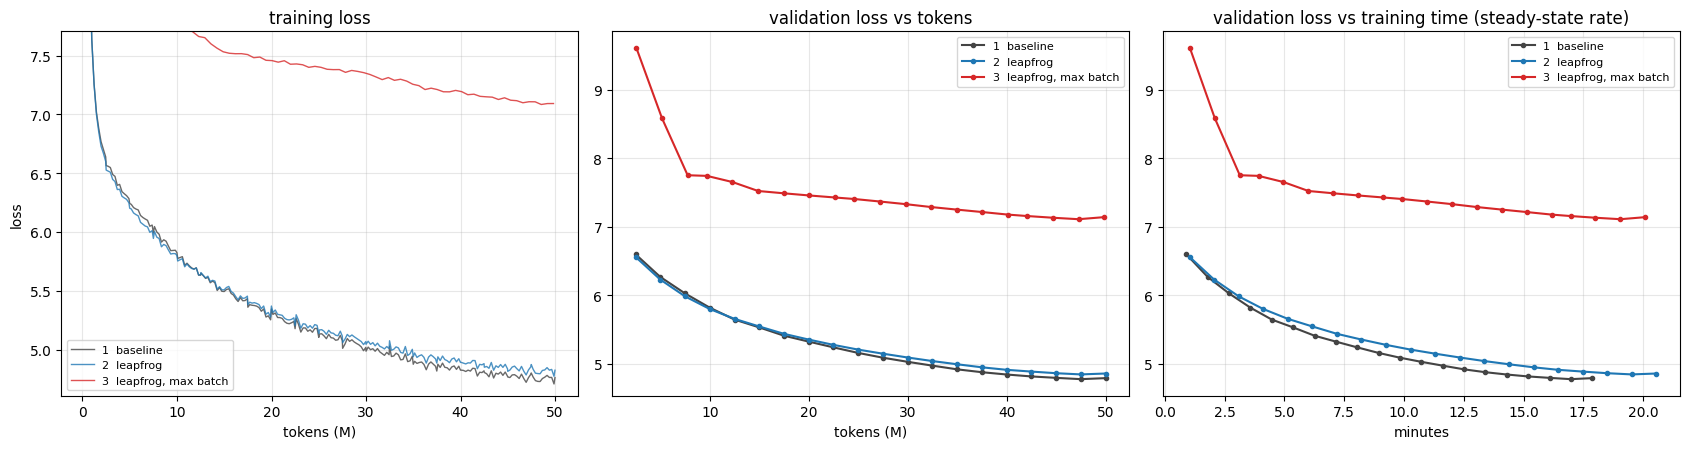

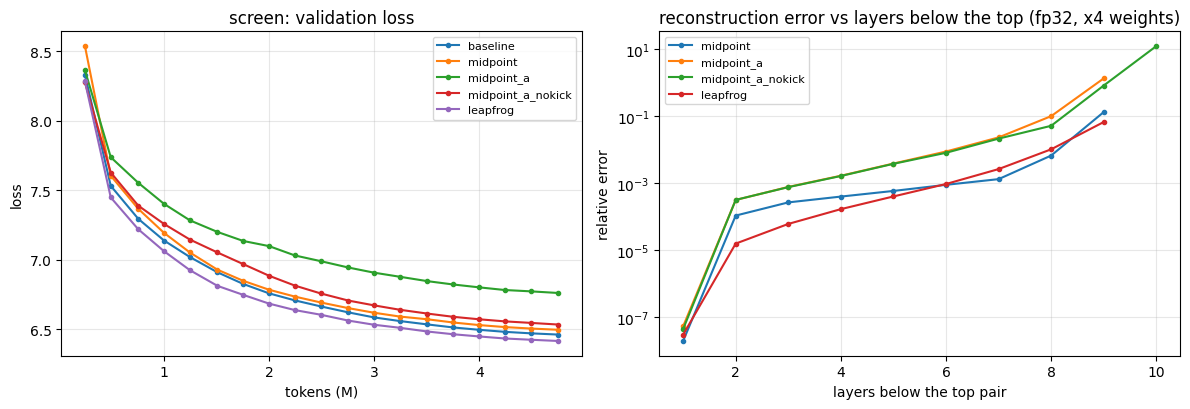

saved /content/s13_runs/s13_curves.png and s13_screen_recon.png


In [19]:
import matplotlib
if OFFLINE: matplotlib.use("Agg")
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
cols = {"1": "#444444", "2": "#1f77b4", "3": "#d62728"}
for label, r in RUNS:
    c = cols[label[0]]
    tk = [p[0] / 1e6 for p in r["curve"]]; ls = [p[1] for p in r["curve"]]
    ax[0].plot(tk, ls, color=c, lw=1, alpha=0.8, label=label.strip())
    vt = [p[0] / 1e6 for p in r["vcurve"]] + [r["tokens"] / 1e6]
    vl = [p[1] for p in r["vcurve"]] + [r["final_val"]]
    ax[1].plot(vt, vl, "o-", color=c, ms=3, label=label.strip())
    sec = [p[0] / r["tok_s"] / 60 for p in r["vcurve"]] + [r["tokens"] / r["tok_s"] / 60]
    ax[2].plot(sec, vl, "o-", color=c, ms=3, label=label.strip())
ax[0].set(title="training loss", xlabel="tokens (M)", ylabel="loss", ylim=(None, None))
ax[1].set(title="validation loss vs tokens", xlabel="tokens (M)")
ax[2].set(title="validation loss vs training time (steady-state rate)", xlabel="minutes")
for a_ in ax: a_.grid(alpha=0.3); a_.legend(fontsize=8)
lo = min(min(p[1] for p in r["curve"] if math.isfinite(p[1])) for _, r in RUNS)
ax[0].set_ylim(lo - 0.1, lo + 3.0)
plt.tight_layout(); plt.savefig(os.path.join(RUN_DIR, "s13_curves.png"), dpi=120)
if not OFFLINE: plt.show()
plt.close(fig)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for k, v in SCREEN.items():
    ax[0].plot([p[0] / 1e6 for p in v["vcurve"]], [p[1] for p in v["vcurve"]], "o-", ms=3, label=k)
ax[0].set(title="screen: validation loss", xlabel="tokens (M)", ylabel="loss"); ax[0].legend(fontsize=8)
for k in REV_VARIANTS:
    ax[1].semilogy(range(1, len(RECON[(k, "fp32", 4.0)]["errs"]) + 1), RECON[(k, "fp32", 4.0)]["errs"],
                   "o-", ms=3, label=k)
ax[1].set(title="reconstruction error vs layers below the top (fp32, x4 weights)",
          xlabel="layers below the top pair", ylabel="relative error"); ax[1].legend(fontsize=8)
for a_ in ax: a_.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(RUN_DIR, "s13_screen_recon.png"), dpi=120)
if not OFFLINE: plt.show()
plt.close(fig)
print("saved", os.path.join(RUN_DIR, "s13_curves.png"), "and s13_screen_recon.png")

## 12 · Findings

Every figure in the cell below is printed from a variable measured in this run.

In [20]:
print("=" * 86)
print(f"{'FINDINGS - all measured in this run':^86}")
print("=" * 86)
print(f"model {N_PARAMS/1e6:.2f}M params, {CFG['layers']} layers, d={CFG['d']}, context {T} | {GPU} | {AMP_DTYPE}")
print(f"data  {MANIFEST['source']}, {RUN1['tokens']/1e6:.1f}M training tokens, one epoch\n")
print(f" 1  variant that worked: {WINNER} - {INTEGRATORS[WINNER]['note']}")
print(f"    screen at {SCREEN['baseline']['tokens']/1e6:.1f}M tokens: " + ", ".join(
      f"{k} {v['final_val']:.3f}" for k, v in sorted(SCREEN.items(), key=lambda kv: kv[1]['final_val'])))
print(f" 2  the reversible backward is exact as an algorithm: {FP32_ORACLE:.1e} vs autograd with true states;")
print(f"    with rebuilt states the gap is reconstruction error, worst {FP32_REBUILT:.1e} in fp32")
print(f" 3  final val loss: baseline {RUN1['final_val']:.4f} | reversible {RUN2['final_val']:.4f}"
      f" ({GAP2:+.4f}) | reversible max batch {RUN3['final_val']:.4f} ({GAP3:+.4f} vs run 2)")
print(f" 4  speed: {RUN1['tok_s']:,.0f} | {RUN2['tok_s']:,.0f} | {RUN3['tok_s']:,.0f} tok/s"
      f" -> reversibility costs {100*OVERHEAD:+.1f}% per token (FLOPs predict {100*PRED_OVERHEAD:.1f}%);"
      f" max batch gives {THRU:.2f}x back")
if RUN1["peak"]:
    print(f" 5  peak memory: {gib(RUN1['peak'])} | {gib(RUN2['peak'])} | {gib(RUN3['peak'])} GiB"
          f" (baseline / reversible at batch {CFG['batch']}: {MEMR:.2f}x)")
print(f" 6  max batch: baseline naive {PROBE['baseline, naive head']:,}, baseline fused {B_BASE:,},"
      f" reversible {B_REV:,} -> {B_REV/max(B_BASE,1):.1f}x")
print(f" 7  the naive head alone is {100*HEAD_SHARE:.0f}% of the baseline's saved activations at this size")
print(f" 8  saved for backward, same rule: plain {plainA/MiB:,.0f} MiB vs RevStack {revA/MiB:,.1f} MiB"
      f" ({SAVED_RATIO:.1f}x); {LAYER_BYTES:.1f} bytes/token/d per layer vs the lesson's estimate")
print(f" 9  midpoint(a) doubles reconstruction error per layer in theory; measured at init"
      f" x{RECON[('midpoint_a','fp32',1.0)]['growth']:.2f}, midpoint x{RECON[('midpoint','fp32',1.0)]['growth']:.2f}")
if TRAINED:
    print(f"10  on trained weights: bottom-state error {TRAINED['bottom']:.1e}, gradient gap {TRAINED['rebuilt']:.1e}")
print(f"11  at a fixed {RUN3['tokens']/1e6:.0f}M-token budget the max-batch run took {RUN3['steps']} steps"
      f" instead of {RUN2['steps']}: throughput up {THRU:.2f}x, loss {GAP3:+.3f}")
print("=" * 86)

                         FINDINGS - all measured in this run                          
model 20.88M params, 10 layers, d=256, context 512 | Tesla T4 | torch.float16
data  fineweb_edu_gpt2, 50.0M training tokens, one epoch

 1  variant that worked: leapfrog - Gal eq. 2.6, the wave equation: h=0.5 so h^2=0.25; bootstrap h^2/2
    screen at 5.0M tokens: leapfrog 6.460, baseline 6.506, midpoint 6.542, midpoint_a_nokick 6.583, midpoint_a 6.802
 2  the reversible backward is exact as an algorithm: 7.6e-07 vs autograd with true states;
    with rebuilt states the gap is reconstruction error, worst 1.1e-02 in fp32
 3  final val loss: baseline 4.7864 | reversible 4.8539 (+0.0675) | reversible max batch 7.1387 (+2.2849 vs run 2)
 4  speed: 46,608 | 40,523 | 41,329 tok/s -> reversibility costs +15.0% per token (FLOPs predict 11.2%); max batch gives 1.02x back
 5  peak memory: 3.14 | 1.75 | 12.71 GiB (baseline / reversible at batch 32: 1.80x)
 6  max batch: baseline naive 37, baseline fused 272, r